Index(['Month', '#Passengers'], dtype='object')
                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Mon, 29 Jun 2026   AIC                           1394.683
Time:                        11:36:33   BIC                           1403.571
Sample:                             0   HQIC                          1398.294
                                - 144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigm

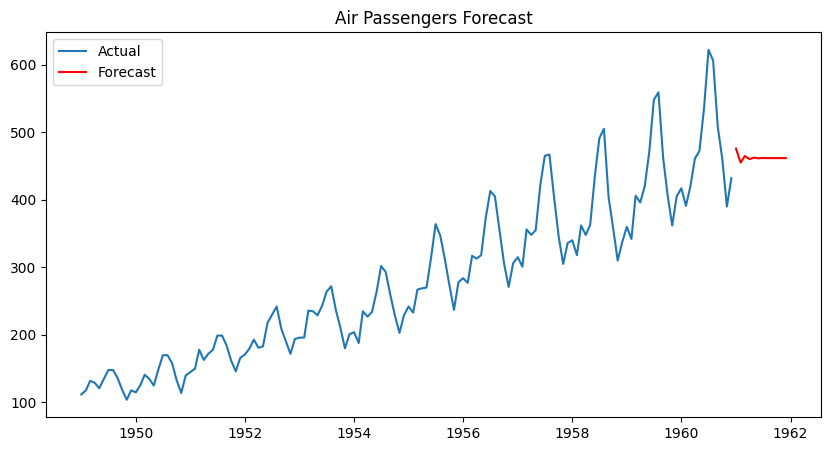

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


df = pd.read_csv("AirPassengers.csv")


print(df.columns)


df["Month"] = pd.to_datetime(df["Month"])

df = df.sort_values("Month")


data = df["#Passengers"]


model = ARIMA(data, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


forecast = model_fit.forecast(steps=12)

print("Forecast:")
print(forecast)


plt.figure(figsize=(10,5))
plt.plot(df["Month"], data, label="Actual")
plt.plot(pd.date_range(df["Month"].iloc[-1], periods=13, freq="MS")[1:],
         forecast,
         label="Forecast",
         color="red")
plt.legend()
plt.title("Air Passengers Forecast")
plt.show()